In [2]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime

In [4]:
lake='geneva'
modal_analysis_dir = f"/storage/alplakes_test/{lake}_100m_2025/modal_analysis"
output_dir = os.path.join(modal_analysis_dir, "figures")

In [5]:
os.makedirs(output_dir, exist_ok=True)

In [6]:
ds_results = xr.open_dataset(os.path.join(modal_analysis_dir, "KE_projected.nc"))

from glob import glob

files = [
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z0-9.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z10-19.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z20-29.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z30-39.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z40-49.nc"))),
]

ds_results = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim=["Z", "time"]
)

ds_results.to_netcdf(os.path.join(modal_analysis_dir, "KE_projected.nc"))

# Compute velocities (from projection)

In [7]:
mode_nb = 0
ds_mode = xr.open_dataset(str(ds_results.mode[mode_nb].values))

In [ ]:
xr_norm2 = xr.open_dataset(os.path.join(modal_analysis_dir, 'norm2.nc'))

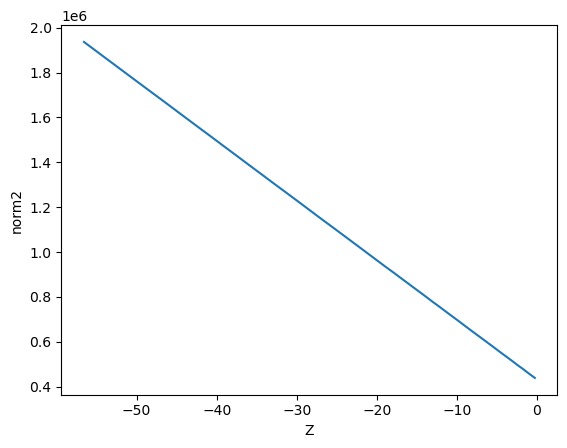

In [15]:
xr_norm2.plot()

In [18]:
A = ds_results.A_real #+ 1j*ds_results.A_imag
mode_u = ds_mode.u1_real + 1j*ds_mode.u1_imag
mode_v = ds_mode.v1_real + 1j*ds_mode.v1_imag
u_proj = A * mode_u/np.sqrt(norm2)
v_proj = A * mode_v/np.sqrt(norm2)

ValueError: operands could not be broadcast together with shapes (1,50,5136,80,181) (100,) 

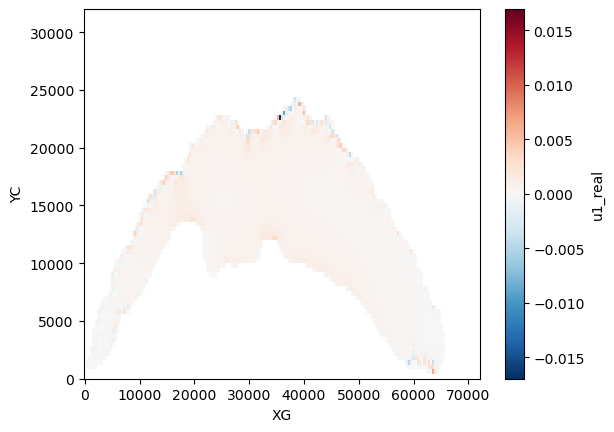

In [17]:
ds_mode.u1_real.plot(cmap='RdBu_r')

# Plot

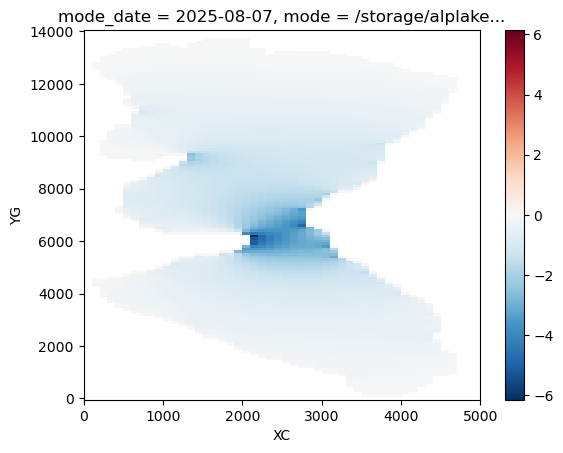

In [ ]:
v_proj.real.isel(mode_date=0, mode=0, Z=0, time=48).plot()

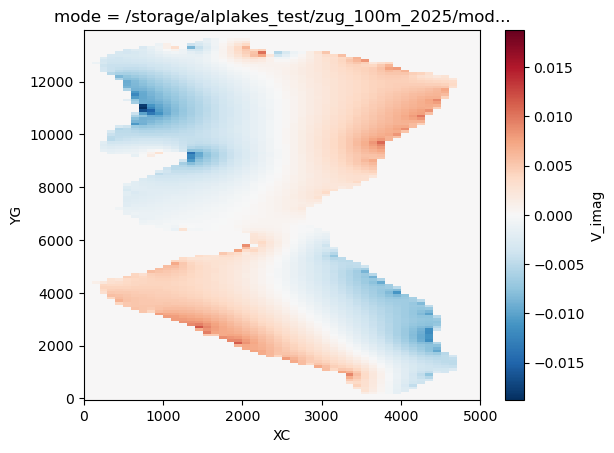

In [10]:
ds_results.V_imag.isel(mode=0, layer=0, time=48).plot()

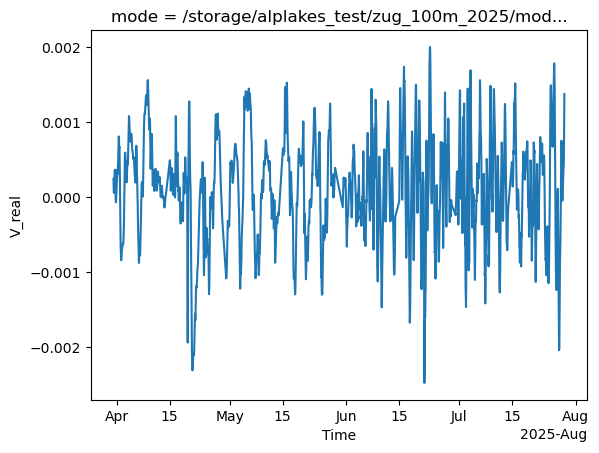

In [13]:
ds_results.V_real.isel(mode=0, layer=1, YG=40, XC=25).plot()

Text(0.02, 0.98, '2025-04-02T00:30:00.000000000')

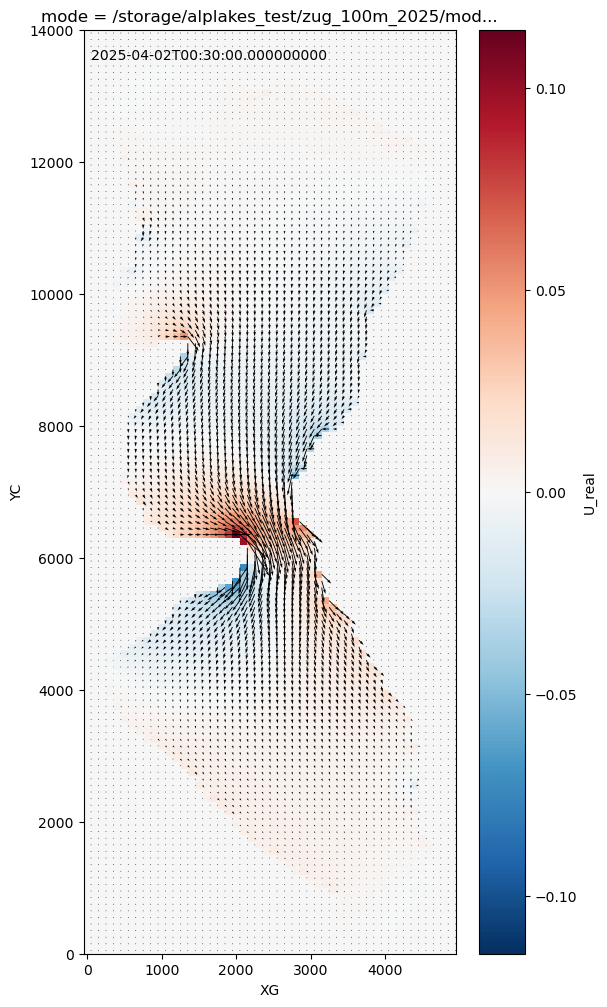

In [17]:
itime = 48
plt.figure(figsize=(6, 12))
u_plot = ds_results.U_real.isel(mode=0, layer=0, time=itime)
v_plot = ds_results.V_real.isel(mode=0, layer=0, time=itime)
x_grid, y_grid = np.meshgrid(v_plot.XC, u_plot.YC)
u_plot.plot()
plt.quiver(x_grid, y_grid, u_plot.values, v_plot.values)
plt.text(0.02, 0.98, f"{u_plot.time.values}", ha='left', va='top', transform=plt.gca().transAxes)

In [ ]:
for itime in range(45*24, 90*24):
    plt.figure(figsize=(6, 12))
    u_plot = ds_results.U_real.isel(mode=0, layer=0, time=itime)
    v_plot = ds_results.V_real.isel(mode=0, layer=0, time=itime)
    x_grid, y_grid = np.meshgrid(v_plot.XC, u_plot.YC)
    u_plot.plot()
    plt.quiver(x_grid, y_grid, u_plot.values, v_plot.values)
    plt.text(0.02, 0.98, f"{u_plot.time.values}", ha='left', va='top', transform=plt.gca().transAxes)
    plt.savefig(os.path.join(output_dir, f"mode_{mode_nb}_projection_time_{itime}.png"))
    plt.close('all')

KeyboardInterrupt: 

<Figure size 600x1200 with 0 Axes>

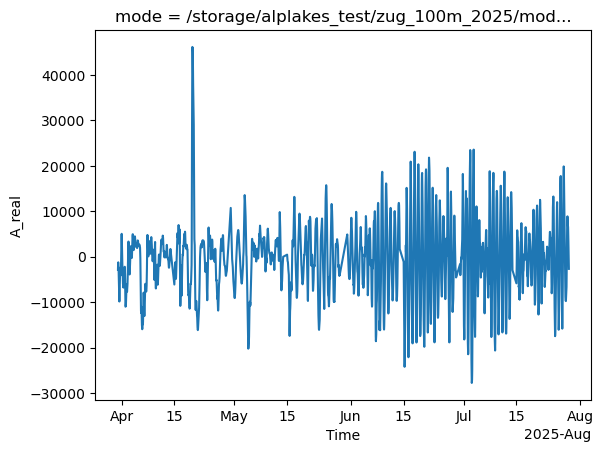

In [18]:
ds_results.A_real.isel(mode=0,layer=0).plot()

# Spectral analysis

In [19]:
import sys
sys.path.append('../../')
from utils_signal_processing import *

In [20]:
time_slice = slice(datetime(2025,4,1), datetime(2025,6,1))
l_seg = len(ds_results.sel(time=time_slice).time)
A_real_fft = xr_compute_meanfft(ds_results.A_real.isel(mode=0, layer=0).sel(time=time_slice), seg_length=l_seg)

/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/python/horizontal_structure_analysis/seiches/modal_analysis/../../utils_signal_processing/fast_fourier_transform.py:79: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  amp_mean, err_up, err_low = xr.apply_ufunc(


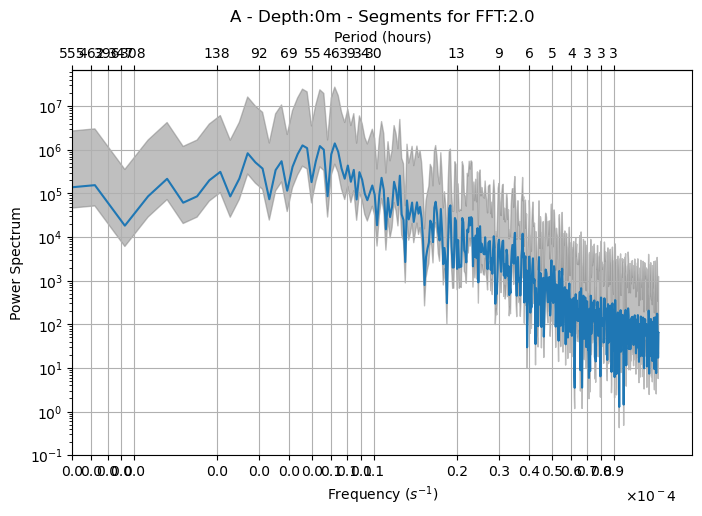

In [22]:
fig,ax = plot_freq_spectrum(A_real_fft, 'A', depth=0, l_segm=l_seg, y_lim_min=1e-1, x_lim_min=5e-7, fontsize=10)

# Comparison with MITgcm results

In [23]:
import sys
sys.path.append('../..')
from utils_mitgcm import open_mitgcm_ds_from_config

In [24]:
lake = 'zug'
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//..//config.json', model)

In [25]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "energy_budget")
os.makedirs(output_folder, exist_ok=True)

In [26]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC']) + 1) * grid_resolution - grid_resolution / 2
ds['XC'] = np.arange(1, len(ds['XC']) + 1) * grid_resolution - grid_resolution / 2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [27]:
mask = ds['THETA'].isel(time=0).values > 0

In [28]:
aligned_u = ds.UVEL.rename({'XG':'XC'})
aligned_u['XC'] = ds['XC']
aligned_u = aligned_u.where(mask, np.nan)

aligned_v = ds.VVEL.rename({'YG':'YC'})
aligned_v['YC'] = ds['YC']
aligned_v = aligned_v.where(mask, np.nan)

aligned_w = ds.WVEL.rename({'Zl':'Z'})
aligned_w['Z'] = ds['Z']
aligned_w = aligned_w.where(mask, np.nan)

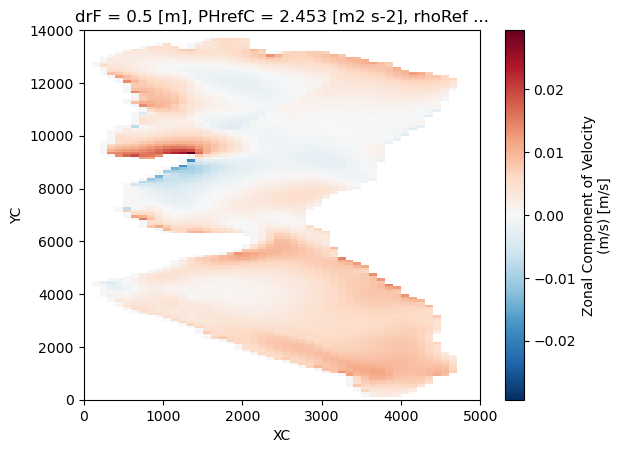

In [29]:
aligned_u.isel(time=50, Z=0).plot()

In [30]:
cutoff2_hr=30
cutoff1_hr=49
u_filtered = xr.open_zarr(os.path.join(folder_path, 'seiche_analysis', f'{cutoff2_hr}_{cutoff1_hr}h', rf"u_filtered_august2025_{cutoff2_hr}-{cutoff1_hr}h.zarr"))
v_filtered = xr.open_zarr(os.path.join(folder_path, 'seiche_analysis', f'{cutoff2_hr}_{cutoff1_hr}h', rf"v_filtered_august2025_{cutoff2_hr}-{cutoff1_hr}h.zarr"))

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


FileNotFoundError: Unable to find group: file:///storage/alplakes_test/zug_100m_2025/seiche_analysis/30_49h/u_filtered_august2025_30-49h.zarr

In [ ]:
mask[0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(96, 390))

In [16]:
aligned_u_filtered = u_filtered.UVEL.rename({'XG':'XC'})
aligned_u_filtered['XC'] = v_filtered['XC']
aligned_u_filtered = aligned_u_filtered.transpose().where(mask[0], np.nan)

aligned_v_filtered = v_filtered.VVEL.rename({'YG':'YC'})
aligned_v_filtered['YC'] = u_filtered['YC']
aligned_v_filtered = aligned_v_filtered.transpose().where(mask[0], np.nan)

In [40]:
itime_start = 4*31*24
offset_time_mitgcm = 31*24

ValueError: setting an array element with a sequence.

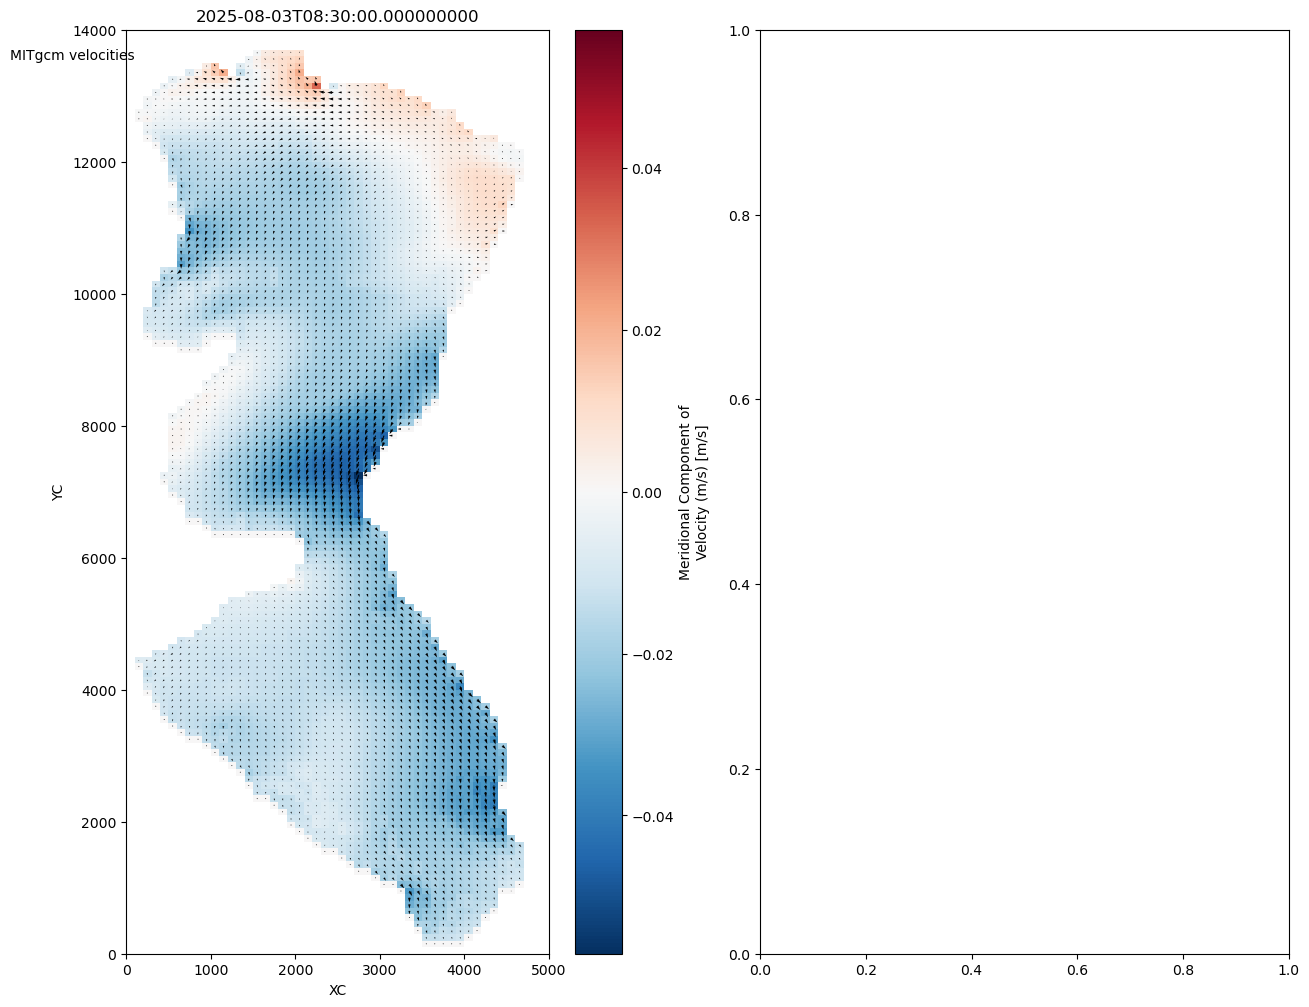

In [ ]:
for itime in range(itime_start, itime_start+14*24):
    fig, axs = plt.subplots(1,2,figsize=(15, 12))
    u_mitgcm = aligned_u.isel(time=itime+offset_time_mitgcm, Z=0)
    v_mitgcm = aligned_v.isel(time=itime+offset_time_mitgcm, Z=0)
    v_mitgcm.plot(ax=axs[0])
    x_grid, y_grid = np.meshgrid(u_mitgcm.XC, u_mitgcm.YC)
    axs[0].quiver(x_grid, y_grid, u_mitgcm, v_mitgcm)
    axs[0].set_title(f"{ds_results.time.isel(time=itime).values}")
    axs[0].text(0.02, 0.98, f"MITgcm velocities", ha='right', va='top', transform=axs[0].transAxes)

    ylim = np.max([np.abs(u_mitgcm.min()), np.abs(u_mitgcm.max())])

    u_plot = ds_results.U_real.isel(mode=0, layer=0, time=itime)
    v_plot = ds_results.V_real.isel(mode=0, layer=0, time=itime)
    ds_results.V_real.isel(mode=0, layer=0, time=itime).plot(vmin=-ylim, vmax=ylim, ax=axs[1], cmap='RdBu_r')
    x_grid, y_grid = np.meshgrid(v_plot.XC, u_plot.YC)
    axs[1].quiver(x_grid, y_grid, u_plot.values, v_plot.values)
    axs[1].set_title(f"")
    axs[1].text(0.02, 0.98, f"Internal Seiche", ha='right', va='top', transform=axs[1].transAxes)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"comparision_time_{itime}.png"))
    plt.close('all')

# Kinetic energy

In [38]:
from utils_energy_analysis import *

In [41]:
itime_start_mitgcm = itime_start + offset_time_mitgcm
ke_surf = compute_ke(aligned_u.isel(time=slice(itime_start_mitgcm, itime_start_mitgcm+14*24), Z=0),
                     aligned_v.isel(time=slice(itime_start_mitgcm, itime_start_mitgcm+14*24), Z=0),
                     aligned_w.isel(time=slice(itime_start_mitgcm, itime_start_mitgcm+14*24), Z=0),
                     100, 100,
                     ds.drF.isel(Z=0))

In [42]:
df_ke_surf = ke_surf.sum(dim=['YC','XC']).to_dataframe(name='kinetic_energy_[MJ]')

<Axes: xlabel='time'>

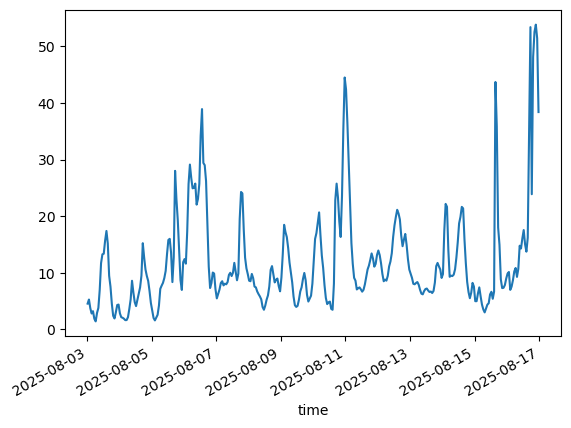

In [43]:
df_ke_surf['kinetic_energy_[MJ]'].plot()

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: title={'center': 'mode_date = 2025-08-07, mode = /storage/alplake...'}, xlabel='time', ylabel='KE'>

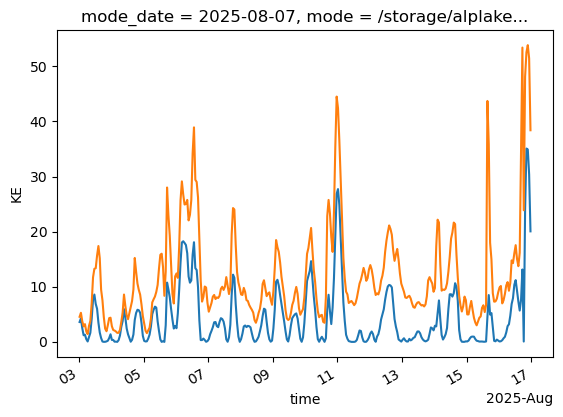

In [44]:
ke_iw = ds_results.KE.isel(mode_date=0, mode=0, Z=0, time=slice(itime_start, itime_start+14*24))/1e6
ke_iw.plot()
df_ke_surf['kinetic_energy_[MJ]'].plot()

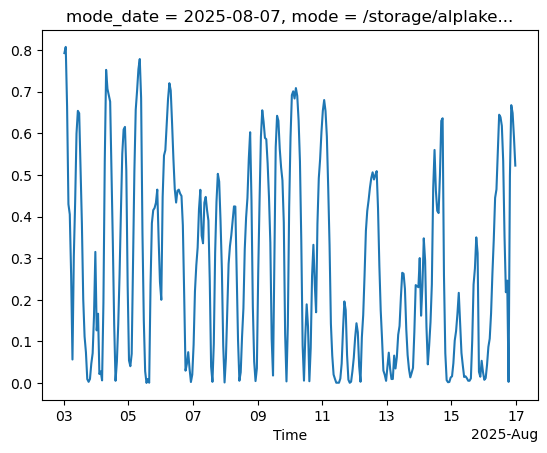

In [45]:
(ke_iw / df_ke_surf['kinetic_energy_[MJ]']).plot()

In [46]:
ke_iw.mean() / df_ke_surf['kinetic_energy_[MJ]'].mean()

<xarray.DataArray 'KE' ()> Size: 8B
array(0.35460452)
Coordinates:
    mode_date  datetime64[ns] 8B 2025-08-07
    mode       <U75 300B '/storage/alplakes_test/zug_100m_2025/modal_analysis...
    Z          float64 8B -0.25
    drF        float32 4B ...
    PHrefC     float32 4B ...
    rhoRef     float32 4B ...